In [10]:
!pip install pandas numpy matplotlib tensorflow scikit-learn wandb nbformat

In [ ]:
import os
import gzip
import json
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.metrics import Precision, Recall, AUC

# Final evaluation metrics (accuracy/precision/recall/f1/roc_auc), computed the same way as the logreg notebook
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

# Data prep (download + label + balance + split)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Experiment tracking (run `pip install wandb` first; in Colab: !pip install wandb)
import wandb
from wandb.integration.keras import WandbMetricsLogger

print(f"TensorFlow Version: {tf.__version__}")

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU support: ENABLED ({len(gpus)} device(s) found)")
    for gpu in gpus:
        print(f"  {gpu}")
else:
    print("GPU support: DISABLED (running on CPU)")

In [ ]:
URL = ("https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/"
       "raw/review_categories/All_Beauty.jsonl.gz")
FILE_NAME = "All_Beauty.jsonl.gz"
TARGET_PER_CLASS = 50_000   #50k positive + 50k negative = 100k total, same cap as the logreg notebook
CHUNK_SIZE = 10_000


def download_dataset(url=URL, file_name=FILE_NAME):
    """Download the dataset once; skip if it is already present."""
    if os.path.exists(file_name):
        print(f"'{file_name}' already exists, skipping download.")
    else:
        print("Downloading dataset (this may take a moment)...")
        urllib.request.urlretrieve(url, file_name)
        print("Download complete.")
    return file_name


def load_raw_dataframe(file_name=FILE_NAME, target_per_class=TARGET_PER_CLASS):
    """Stream the JSONL.GZ file into a class-balanced DataFrame, stopping early
    once `target_per_class` reviews have been collected for both classes
    (mirrors the logistic-regression notebook's loader).
    """
    download_dataset(file_name=file_name)
    print("Streaming JSONL.GZ file into a balanced dataset...")

    pos_list, neg_list = [], []
    chunk = []
    with gzip.open(file_name, "rt", encoding="utf-8") as f:
        for line in f:
            chunk.append(json.loads(line))
            if len(chunk) == CHUNK_SIZE:
                cdf = pd.DataFrame(chunk).dropna(subset=["text", "rating"])
                pos_list.append(cdf[cdf["rating"] >= 4])
                neg_list.append(cdf[cdf["rating"] <= 2])
                chunk = []

                cur_pos = sum(len(c) for c in pos_list)
                cur_neg = sum(len(c) for c in neg_list)
                print(f"  Collected: {cur_pos:,} Pos | {cur_neg:,} Neg ...", end="\r")
                if cur_pos >= target_per_class and cur_neg >= target_per_class:
                    print("\n  Target reached! Stopping stream.")
                    break

    df_pos = pd.concat(pos_list).iloc[:target_per_class]
    df_neg = pd.concat(neg_list).iloc[:target_per_class]

    # 3-star reviews that were naturally excluded
    with gzip.open(file_name, "rt", encoding="utf-8") as f:
        neutral_count = sum(1 for line in f if json.loads(line).get("rating") == 3.0)

    df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Loaded {len(df):,} records "
          f"({len(df_pos):,} positive, {len(df_neg):,} negative, {neutral_count:,} neutral dropped).")
    return df, neutral_count


def load_review_data(text_field="full_text", test_size=0.25, seed=42):
    """Label and split the reviews (already balanced + capped by
    load_raw_dataframe).

    Parameters
    ----------
    text_field : which text column to feed the model. Default "full_text"
        (title + text) gives the model maximum context.
    test_size, seed : passed to a stratified train/test split.

    Returns
    -------
    dict with keys:
        df       : the balanced, shuffled DataFrame (for the EDA plots)
        X_train, X_test, y_train, y_test : the canonical split
        counts   : raw + balanced class counts for the distribution charts
    """
    df, neutral_count = load_raw_dataframe()

    # Combine title + text for maximum context
    df = df.copy()
    df["full_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    df = df[df["full_text"].str.strip() != ""]

    df["sentiment"] = (df["rating"] >= 4).astype(int)

    raw_pos = int((df["sentiment"] == 1).sum())
    raw_neg = int((df["sentiment"] == 0).sum())
    per_class = min(raw_pos, raw_neg)

    # The one canonical split reused for train/test
    X = df[text_field]
    y = df["sentiment"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )

    counts = {
        "raw_negative": raw_neg,
        "raw_neutral": neutral_count,
        "raw_positive": raw_pos,
        "dropped_3_star": neutral_count,
        "balanced_per_class": per_class,
        "balanced_total": len(df),
    }

    print(f"\nDataset ready: {counts['balanced_total']:,} balanced reviews "
          f"({per_class:,} per class); {neutral_count:,} neutral (3-star) dropped.")
    print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

    return {
        "df": df,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "counts": counts,
    }

In [ ]:
# Load the balanced, split dataset
data = load_review_data()

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
counts  = data["counts"]

print(f"Using {len(X_train):,} training reviews")

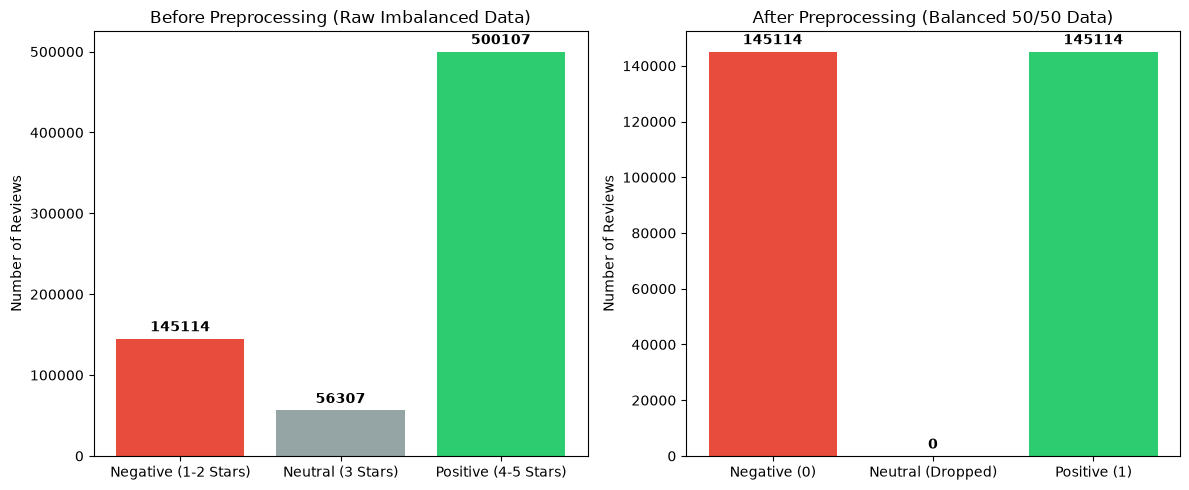

In [14]:
# Visualization of class distributions (uses the shared counts)
raw_neg = counts["raw_negative"]
raw_neu = counts["raw_neutral"]
raw_pos = counts["raw_positive"]

bal_neg = counts["balanced_per_class"]
bal_neu = 0  # 3-star reviews were dropped
bal_pos = counts["balanced_per_class"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories_before = ['Negative (1-2 Stars)', 'Neutral (3 Stars)', 'Positive (4-5 Stars)']
counts_before = [raw_neg, raw_neu, raw_pos]
axes[0].bar(categories_before, counts_before, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Before Preprocessing (Raw Imbalanced Data)')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts_before):
    axes[0].text(i, v + (max(counts_before)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

categories_after = ['Negative (0)', 'Neutral (Dropped)', 'Positive (1)']
counts_after = [bal_neg, bal_neu, bal_pos]
axes[1].bar(categories_after, counts_after, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('After Preprocessing (Balanced 50/50 Data)')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(counts_after):
    axes[1].text(i, v + (max(counts_after)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Model-specific preprocessing: turn text into padded integer sequences for the LSTM.

vocab_size = 15000   # Number of unique words to keep
max_length = 120     # Max length of a review
trunc_type = 'post'  # Truncate long reviews at the end
padding_type = 'post'# Pad short reviews at the end
oov_tok = "<OOV>"    # Token for Out Of Vocabulary words

print("Fitting the tokenizer...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Convert text into padded sequences of numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Training data shape: {train_padded.shape}")
print(f"Testing data shape: {test_padded.shape}")

Fitting the tokenizer...
Training data shape: (50000, 120)
Testing data shape: (72557, 120)


In [16]:
# Cell 5
embedding_dim = 64

model = Sequential([
    # Turns positive integers into dense vectors of fixed size
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # Bidirectional LSTM to capture contextual dependencies
    Bidirectional(LSTM(64, return_sequences=True)),

    # Condense the output to the most important features
    GlobalMaxPooling1D(),

    # Fully connected layers with Dropout to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output layer: Sigmoid returns a probability between 0 and 1
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])

model.summary()

/home/benji/aiml/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_epochs = 50 # It will use early stopping anyway to stop when the model becomes good enough
batch_size = 265

# Log in to Weights & Biases (prompts for your API key the first time;
# set WANDB_MODE=offline to skip uploading, or WANDB_MODE=disabled to turn it off)
wandb.login()

# Start a run and record the hyperparameters / dataset sizes for this experiment
run = wandb.init(
    entity="aiml2026",                    # the TEAM - without this, runs go to your personal workspace
    project="amazon-sentiment-analysis",  # shared project - teammates log their models here too
    group="neural-net",                 # this approach (logreg team uses group="logreg", etc.)
    job_type="train",
    name="Bidirectional-LSTM",
    tags=["bilstm"],
    config={
        "model": "Bidirectional LSTM",
        "vocab_size": vocab_size,
        "max_length": max_length,
        "embedding_dim": embedding_dim,
        "lstm_units": 64,
        "dropout": 0.5,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "epochs": num_epochs,
        "batch_size": batch_size,
        "train_samples": len(X_train),
        "test_samples": len(X_test),
    },
)

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Starting model training...")
history = model.fit(
    train_padded, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(test_padded, y_test),
    callbacks=[early_stopping, WandbMetricsLogger()]
)

# Final evaluation on the held-out test set: accuracy, precision, recall, f1-score, roc_auc
y_proba = model.predict(test_padded, verbose=0).ravel()
y_pred = (y_proba > 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)

print("\n--- MODEL PERFORMANCE (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Log the final summary metrics to W&B
wandb.log({
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC_AUC": test_roc_auc,
})

# NOTE: wandb.finish() is called in the next cell, after the confusion matrix
# and ROC curve plots are logged as images to the same run.

In [ ]:
# Confusion Matrix + ROC Curve (Test Set)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bidirectional LSTM – Evaluation", fontsize=14, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#2ecc71", lw=2, label=f"ROC AUC = {test_roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Log as native W&B charts (not static images) so they can be overlaid/compared
# against the logreg and naive-bayes runs in the same project.
y_true_arr = np.asarray(y_test)
y_probas = np.column_stack([1 - y_proba, y_proba])  # wandb wants a column per class

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=y_true_arr,
        preds=y_pred,
        class_names=["Negative", "Positive"],
    ),
    "roc_curve": wandb.plot.roc_curve(
        y_true=y_true_arr,
        y_probas=y_probas,
        labels=["Negative", "Positive"],
    ),
})
wandb.finish()

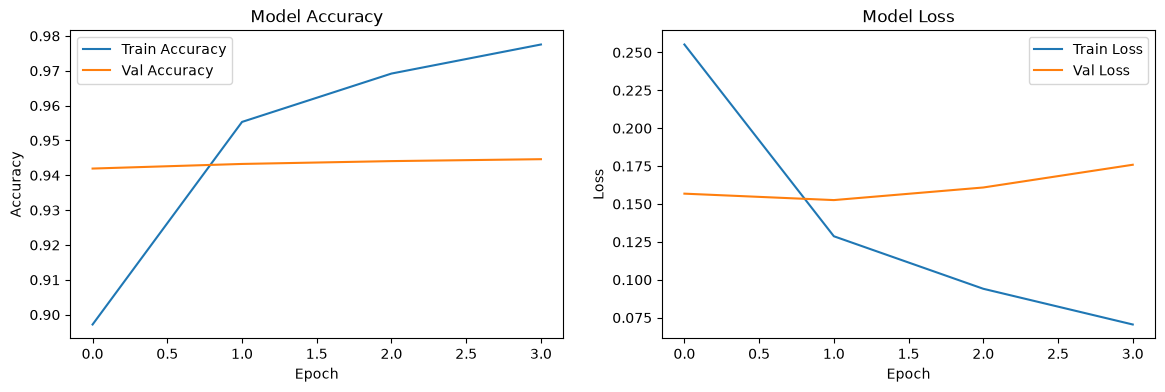

Review: 'These shoes look amazing and fit perfectly. Best purchase ever!'
Sentiment: Positive (Confidence Score: 0.9998)

Review: 'Terrible quality. The fabric ripped after one wash. Do not buy.'
Sentiment: Negative (Confidence Score: 0.0007)

Review: 'It's okay, but honestly a little overpriced for what you get.'
Sentiment: Negative (Confidence Score: 0.1365)



In [18]:
# Cell 7
# Plot Accuracy and Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()

# --- Custom Review Tester ---
def predict_sentiment(review_text):
    # Process the raw text into the format the model expects
    seq = tokenizer.texts_to_sequences([review_text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Predict
    pred = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if pred > 0.5 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} (Confidence Score: {pred:.4f})\n")

# Try it out with your own phrases!
predict_sentiment("These shoes look amazing and fit perfectly. Best purchase ever!")
predict_sentiment("Terrible quality. The fabric ripped after one wash. Do not buy.")
predict_sentiment("It's okay, but honestly a little overpriced for what you get.")